## Best Volatile

Identify the stocks which changes a lot in last 3 weeks. We can get in at the max drop.

In [81]:
%matplotlib inline
from pyspark.sql import SparkSession
from pyspark.sql.functions import col,dayofweek,current_date,date_sub,to_date,abs,lit
from pyspark.sql.functions import sum as spark_sum,max as spark_max, min as spark_min
from datetime import datetime, timedelta
import configparser
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pyspark.sql import DataFrame
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import DoubleType
from grid_chart_util import create_stock_price_grid
from spark_init import initialize_spark
from config_loader import load_config

In [82]:
# Get date threshold (last 3 weeks)
date_threshold = datetime.today() - timedelta(weeks=3)

In [83]:
tablename = "stocksinfp"
earning_table = "stocks_earnings"
# Load configuration details
try:
    url, driver, username, password = load_config()
    print(f"URL: {url}, Driver: {driver}, Username: {username}, Table: {tablename}")
except Exception as e:
    print(f"Error loading config: {e}")
spark = initialize_spark("25BestVolatile")

URL: jdbc:mysql://localhost/stocksdb, Driver: com.mysql.cj.jdbc.Driver, Username: quizadmin, Table: stocksinfp
Error loading config: name 'some_other_param' is not defined


In [84]:
stock_df = spark.read.format("jdbc").options(url=url, driver=driver, user=username, password=password, dbtable=tablename).load()
earnings_df = spark.read.format("jdbc").options(url=url, driver=driver, user=username, password=password, dbtable=earning_table).load()
#stock_df = stock_df.filter((col("Symbol").isin(['UPST']))  ) #| (col("Symbol") == 'PANW')
#spark.sparkContext.stop()

In [85]:
earnings_df = earnings_df.select("Symbol","earnings_date")

In [86]:
# Convert types
df = stock_df.withColumn("Date", to_date(col("Date"))) \
       .withColumn("Open", col("Open").cast("double")) \
       .withColumn("price_change", col("price_change").cast("double"))



In [87]:
# Filter last 3 weeks
df = df.filter(col("Date") >= date_threshold)


In [88]:
df = df.alias("df")
earnings_df = earnings_df.alias("earnings_df")
#df.printSchema()
#earnings_df.printSchema()
er_filterdf = df.join(earnings_df, df["symbol"] == earnings_df["Symbol"], "inner") \
       .drop(earnings_df["Symbol"])  # Dropping duplicate column

#er_filterdf.show()

In [89]:
# Calculate daily % price change using price_change column
er_filterdf = er_filterdf.withColumn("daily_percent_change", abs(col("price_change") / col("Open")) * 100)

In [90]:
# Calculate max and min close prices for each symbol
stock_peaks_df = er_filterdf.groupBy("symbol").agg(
    F.max("Close").alias("max_close"),
    F.min("Close").alias("min_close")
)


In [91]:
# Join the calculated peaks back to the original dataframe
df_with_peaks = er_filterdf.join(stock_peaks_df, on="symbol", how="left")

# Filter out symbols where the difference between max_close and min_close is less than 1
df_filtered = df_with_peaks.filter(F.col("max_close") - F.col("min_close") >= 1)

# Show the resulting DataFrame
#df_filtered.show()

In [92]:
# Sum daily % changes per stock over the last 3 weeks
volatility_df = df_filtered.groupBy("symbol").agg(spark_sum("daily_percent_change").alias("total_volatility"))



In [93]:
# Rank stocks by total volatility (descending)
volatile_stocks = volatility_df.orderBy(col("total_volatility").desc()).limit(25)

# Show results
#volatile_stocks.show()

In [94]:
# Define function to check if date is Monday (2), Wednesday (4), or Friday (6)
def is_mwf(date_col):
    return (dayofweek(date_col) == 2) | (dayofweek(date_col) == 4) | (dayofweek(date_col) == 6)



In [95]:
# Filter last 3 weeks and only MWF data
mwf_df = df_filtered.filter((col("Date") >= lit(date_threshold)) & is_mwf(col("Date")))

# Compute Total Volatility Score (sum of absolute daily percentage changes)
volatility_scores = (
    er_filterdf.groupBy("symbol")
    .agg(spark_sum(abs(col("daily_percent_change"))).alias("volatility_score"))
    .orderBy(col("volatility_score").desc())
)

In [96]:
# Keep only the top 25 most volatile stocks
top_25_stocks = [row["symbol"] for row in volatile_stocks.collect()]
mwf_df = mwf_df.filter(col("symbol").isin(top_25_stocks))

# Compute max and min close price per symbol for highlighting peaks
stock_peaks = mwf_df.groupBy("symbol").agg(
    spark_max("Close").alias("max_close"),
    spark_min("Close").alias("min_close")
)
#stock_peaks.show()

In [97]:
# Convert PySpark DataFrame to Pandas for plotting
pandas_df = mwf_df.select("Date", "symbol", "Close","earnings_date").toPandas()
volatility_scores_pd = volatility_scores.toPandas()
peaks_df = stock_peaks.toPandas()



In [98]:
# Convert Date to datetime format for sorting
pandas_df["Date"] = pd.to_datetime(pandas_df["Date"])

In [99]:
# Merge volatility scores and peaks for display, ensuring all stocks exist
pandas_df = pandas_df.merge(volatility_scores_pd, on="symbol", how="left")
pandas_df = pandas_df.merge(peaks_df, on="symbol", how="left")

In [100]:
# Drop rows that have missing volatility score or peak values
pandas_df.dropna(subset=["volatility_score", "max_close", "min_close"], inplace=True)


In [101]:
#pandas_df

In [102]:
# Regenerate the top 25 stocks list after filtering
top_25_stocks = pandas_df["symbol"].unique().tolist()

In [103]:
# Generate unique colors for each stock using seaborn's color palette
palette = sns.color_palette("husl", len(top_25_stocks))  # Dynamically adjust based on available stocks
color_map = {stock: palette[i] for i, stock in enumerate(top_25_stocks)}


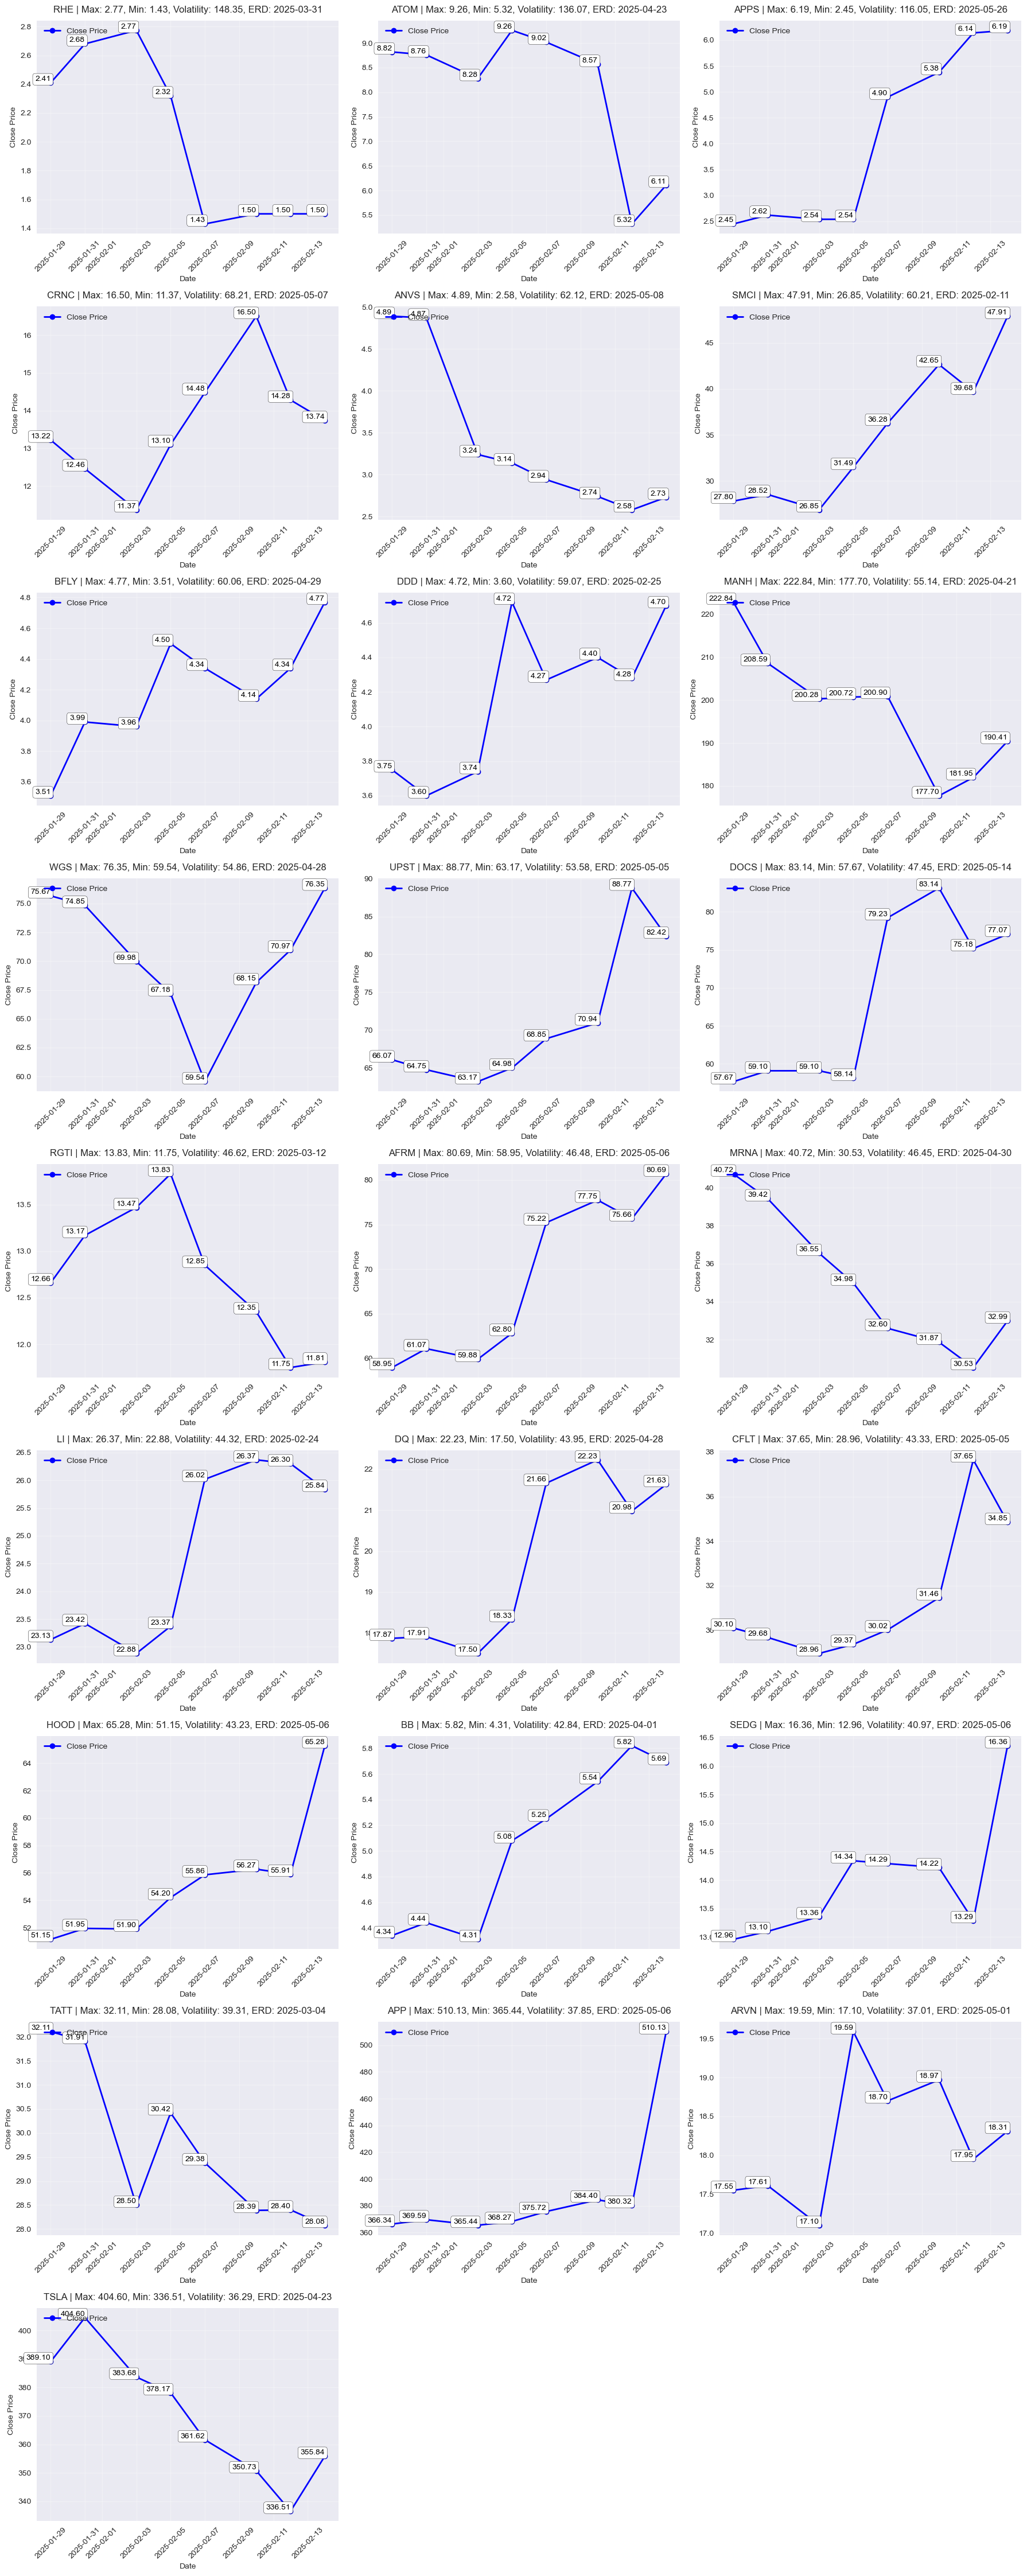

In [104]:
fig = create_stock_price_grid(pandas_df, top_25_stocks)
plt.show()